# Week 3 Day 1 — Linear / Softmax Regression, MLP
**Jul 13, 2026**

Week 1 covered binary classification (`BCEWithLogitsLoss`, one output logit). Today: **multi-class** classification — 3 classes instead of 2 — which is where "linear regression" and "softmax regression" turn out to be the same model wearing different clothes: a single `nn.Linear` layer, just paired with `CrossEntropyLoss` instead of `MSELoss`. Then the same underfitting-to-MLP story as Day 5, replayed for the multi-class case.

Scaffold as usual: TODO stubs, hints not formulas, self-check cells.

## Part 1: A 3-class dataset that a straight line can't solve

Given. One class as an inner blob near the origin, the other two splitting an outer ring in half. Note this is a strictly harder version of Day 5's XOR motivation — no single hyperplane per class can carve out a circular inner region.

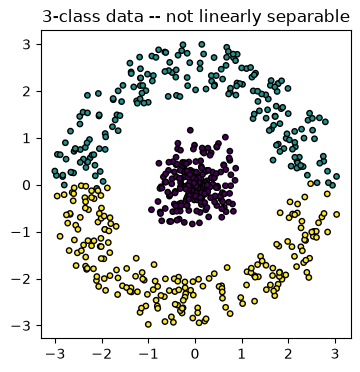

torch.Size([600, 2]) torch.Size([600]) tensor([0, 1, 2])


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)
n_per_class = 200

r0 = torch.rand(n_per_class) * 1.0
theta0 = torch.rand(n_per_class) * 2 * torch.pi
x0 = torch.stack([r0 * torch.cos(theta0), r0 * torch.sin(theta0)], dim=1)

r1 = 2.0 + torch.rand(n_per_class) * 1.0
theta1 = torch.rand(n_per_class) * torch.pi
x1 = torch.stack([r1 * torch.cos(theta1), r1 * torch.sin(theta1)], dim=1)

r2 = 2.0 + torch.rand(n_per_class) * 1.0
theta2 = torch.pi + torch.rand(n_per_class) * torch.pi
x2 = torch.stack([r2 * torch.cos(theta2), r2 * torch.sin(theta2)], dim=1)

X = torch.cat([x0, x1, x2]) + 0.1 * torch.randn(3 * n_per_class, 2)
y = torch.cat([torch.zeros(n_per_class), torch.ones(n_per_class), 2 * torch.ones(n_per_class)]).long()

plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", s=15)
plt.title("3-class data -- not linearly separable")
plt.show()

print(X.shape, y.shape, y.unique())

## Part 2: Softmax regression == linear regression + CrossEntropyLoss

TODO: build `softmax_model`, a **single** `nn.Linear(2, 3)` — no hidden layer, no activation. That's the whole model.

This is the same shape of object as every linear layer you've built before; what makes it "softmax regression" isn't the model architecture, it's the loss function in Part 3. Output 3 raw logits (one score per class), analogous to the single logit from Day 5's binary case, just generalized to `n_classes` outputs instead of 1.

In [2]:
# TODO: softmax_model = nn.Linear(...)
softmax_model = nn.Linear(2, 3)

# self-check
out = softmax_model(X[:5])
assert out.shape == (5, 3), f"expected (5, 3), got {tuple(out.shape)}"
print("shape OK")

shape OK


## Part 3: `CrossEntropyLoss` — a dtype gotcha coming from Week 1/2

TODO: `criterion = nn.CrossEntropyLoss()`, plus an optimizer over `softmax_model.parameters()`.

`CrossEntropyLoss` combines softmax and negative-log-likelihood internally (same "numerically stable, don't apply the activation yourself" pattern as `BCEWithLogitsLoss`) — so the model output should stay raw logits, shape `(batch, n_classes)`, same as Part 2 already gives you.

The real gotcha is the **target**. `BCEWithLogitsLoss` wanted `yb` as `float`, same shape as the output. `CrossEntropyLoss` wants something different: `y` should already be `torch.long` (integer class indices like `0`, `1`, `2` — which is exactly what `y` already is from Part 1), shape `(batch,)`, **not** `(batch, n_classes)` and **not** one-hot. Try passing a float-typed target through it once, on purpose, and read what error comes back — better to see it now on a throwaway line than debug it cold later.

In [5]:
# TODO: criterion = ...
criterion = nn.CrossEntropyLoss()

# TODO: optimizer = ...
optimizer = torch.optim.SGD(softmax_model.parameters(), lr=0.1)

logits = softmax_model(X[:5])

# see the dtype gotcha yourself (uncomment to try, then comment back out):
loss = criterion(logits, y[:5].long())

## Part 4: Train and evaluate

TODO: a standard training loop (full-batch is fine here, no `DataLoader` needed for a dataset this small) plus an `accuracy(model, X, y)` helper.

For accuracy: `model(X)` gives `(n_samples, 3)` logits. Getting a hard class prediction from multi-class logits isn't a sign-of-logit trick like Day 5's binary case — think about which single PyTorch tensor method picks out, per row, the index of the largest value.

In [7]:
def accuracy(model, X, y):
    # TODO: return accuracy as a float
    with torch.no_grad():
        logits = model(X)
        preds = logits.argmax(dim=1)
        acc = (preds == y).float().mean()
    return acc.item()

n_epochs = 300
for epoch in range(n_epochs):
    # TODO: standard training step
    optimizer.zero_grad() #clear previous gradients
    
    logits = softmax_model(X) #forward pass
    loss = criterion(logits, y.long())
    
    loss.backward()
    optimizer.step()
   

print(f"softmax regression train accuracy: {accuracy(softmax_model, X, y):.3f}")

softmax regression train accuracy: 0.838


Expect this to land well below 100% -- a linear decision boundary structurally cannot isolate the inner circular class. That's not a bug in your training loop; it's the model class being the wrong shape for the problem, same lesson as Day 5's XOR.

## Part 5: Multi-class MLP

TODO: build `mlp_model` -- same `Linear -> ReLU -> Linear` shape as Day 5's `MLPClassifier`, but the final layer now outputs 3 logits instead of 1. Train it the same way as Part 4, using the same `criterion`.

In [8]:
# TODO: mlp_model = nn.Sequential(...)
mlp_model = nn.Sequential(
    nn.Linear(2, 25),
    nn.ReLU(),
    nn.Linear(25, 3)
)

# TODO: mlp_optimizer = ...
mlp_optimizer = torch.optim.SGD(mlp_model.parameters(), lr=0.1)

for epoch in range(n_epochs):
    # TODO: standard training step for mlp_model
    mlp_optimizer.zero_grad()
    
    logits = mlp_model(X)
    loss = criterion(logits, y.long())
    
    loss.backward()
    mlp_optimizer.step()
    mlp_optimizer.zero_grad()

print(f"MLP train accuracy: {accuracy(mlp_model, X, y):.3f}")

MLP train accuracy: 0.997


## Part 6: See both decision boundaries

Given, once both models above are trained. Multi-class version of Day 5's boundary plot -- uses `argmax` over 3 classes' logits per grid point instead of a sigmoid threshold.

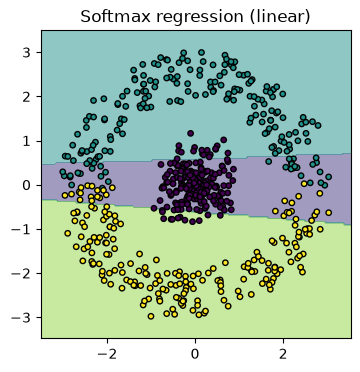

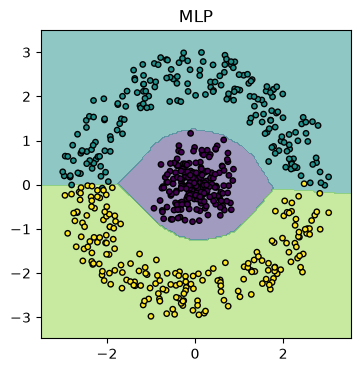

In [9]:
def plot_multiclass_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 200), torch.linspace(y_min, y_max, 200), indexing="xy"
    )
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

    model.eval()
    with torch.no_grad():
        preds = model(grid).argmax(dim=1).reshape(xx.shape)

    plt.figure(figsize=(4, 4))
    plt.contourf(xx.numpy(), yy.numpy(), preds.numpy(), levels=[-0.5, 0.5, 1.5, 2.5], cmap="viridis", alpha=0.5)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", s=15)
    plt.title(title)
    plt.show()

plot_multiclass_boundary(softmax_model, X, y, "Softmax regression (linear)")
plot_multiclass_boundary(mlp_model, X, y, "MLP")

## Try yourself

1. Count parameters in `softmax_model` vs `mlp_model` (`sum(p.numel() for p in model.parameters())`). How much extra capacity did it take to solve a problem the linear model structurally can't?
2. Compute per-class accuracy (not just overall) for both models -- does the linear model fail uniformly across classes, or worse on one specific class? Think about which class's region a hyperplane would have the hardest time isolating.
3. Shrink the MLP's `hidden_dim` down until it starts failing too -- is there a minimum hidden size below which it can't separate this data, similar to Day 5's linear-collapse experiment?
4. Try `nn.functional.softmax(logits, dim=1)` on `mlp_model`'s raw output for a few samples and look at the actual probabilities, not just the `argmax` class -- how confident is the model on points near a class boundary vs. deep inside a class's region?